In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    auc
)

from sklearn.model_selection import cross_val_score

In [3]:
#Load Dataset
customers = pd.read_csv("customers_feature_engineered.csv")

In [4]:
#Load Saved Model
model = joblib.load("lead_prediction_model.pkl")

In [5]:
#Encode Categorical Variables
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [

"Gender",
"Occupation",
"Region",
"Branch",
"FCYAccount",
"ETBAccount",
"MobileBanking",
"InternetBanking",
"AgeGroup"

]

for col in categorical_columns:
    customers[col] = encoder.fit_transform(customers[col])

In [6]:
#Create Features

X = customers.drop(
    columns=[
        "CustomerID",
        "LeadStatus"
    ]
)

y = customers["LeadStatus"]

In [7]:
#Predict
y_pred = model.predict(X)

y_prob = model.predict_proba(X)[:,1]

In [8]:
#Classification Report

print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.58      0.74       407
           1       0.35      1.00      0.52        93

    accuracy                           0.66       500
   macro avg       0.68      0.79      0.63       500
weighted avg       0.88      0.66      0.70       500



Business Interpretation
Precision → If the model predicts a lead, how often is it correct?
Recall → How many actual leads did the model identify?
F1 Score → Balance between Precision and Recall.

For banking campaigns, Recall is often more important because missing a good lead means losing a potential customer.

In [9]:
#Confusion Matrix

cm = confusion_matrix(y, y_pred)

cm

array([[237, 170],
       [  0,  93]])

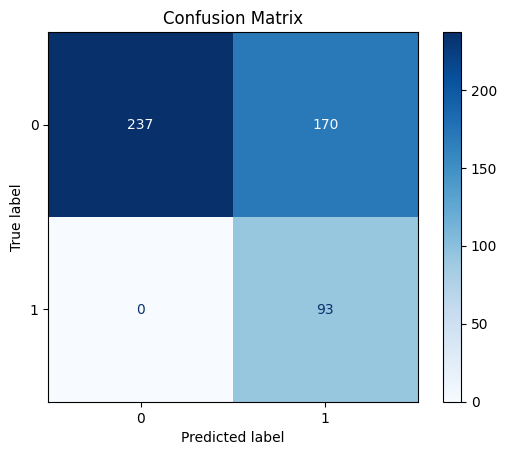

In [10]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [11]:
#Accuracy

accuracy = np.mean(y_pred == y)

print(f"Accuracy : {accuracy:.2%}")

Accuracy : 66.00%


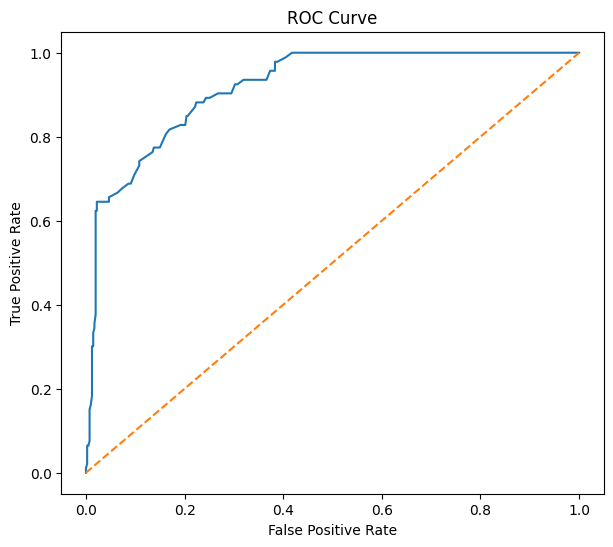

In [12]:
#ROC Curve

fpr, tpr, thresholds = roc_curve(y, y_prob)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [13]:
#ROC AUC Score
roc_score = roc_auc_score(y, y_prob)

print(f"ROC AUC : {roc_score:.4f}")

ROC AUC : 0.9186


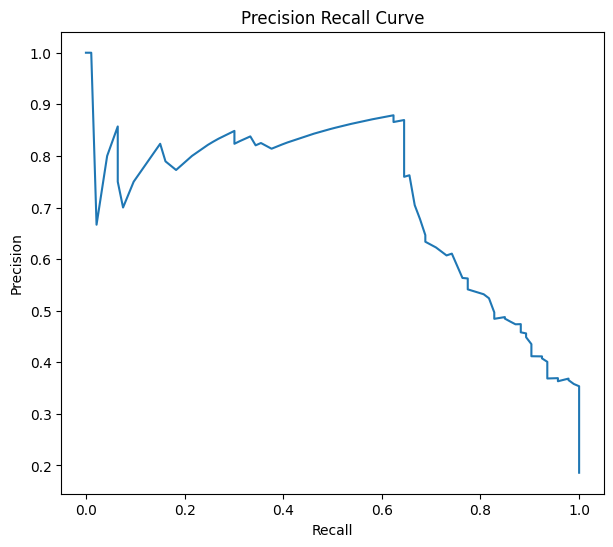

In [14]:
#Precision-Recall Curve

precision, recall, threshold = precision_recall_curve(y, y_prob)

plt.figure(figsize=(7,6))

plt.plot(recall, precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

In [15]:
#PR AUC

pr_auc = auc(recall, precision)

print(pr_auc)

0.7154610250517226


In [16]:
#Cross Validation

scores = cross_val_score(

model,

X,

y,

cv=5,

scoring="accuracy"

)

print(scores)

[1.   1.   0.99 1.   1.  ]


In [17]:
#Feature Importance

importance = pd.DataFrame({

"Feature":X.columns,

"Importance":model.feature_importances_

})

importance = importance.sort_values(

by="Importance",

ascending=False

)

importance

,Feature,Importance
10,RemittanceCount,0.383111
6,FCYAccount,0.297643
8,MobileBanking,0.230055
11,TotalRemittanceUSD,0.065518
26,PotentialFCYCustomer,0.002909
21,DigitalCustomer,0.002364
1,Gender,0.002077
9,InternetBanking,0.001991
3,MonthlyIncome,0.001795
25,RelationshipScore,0.001792


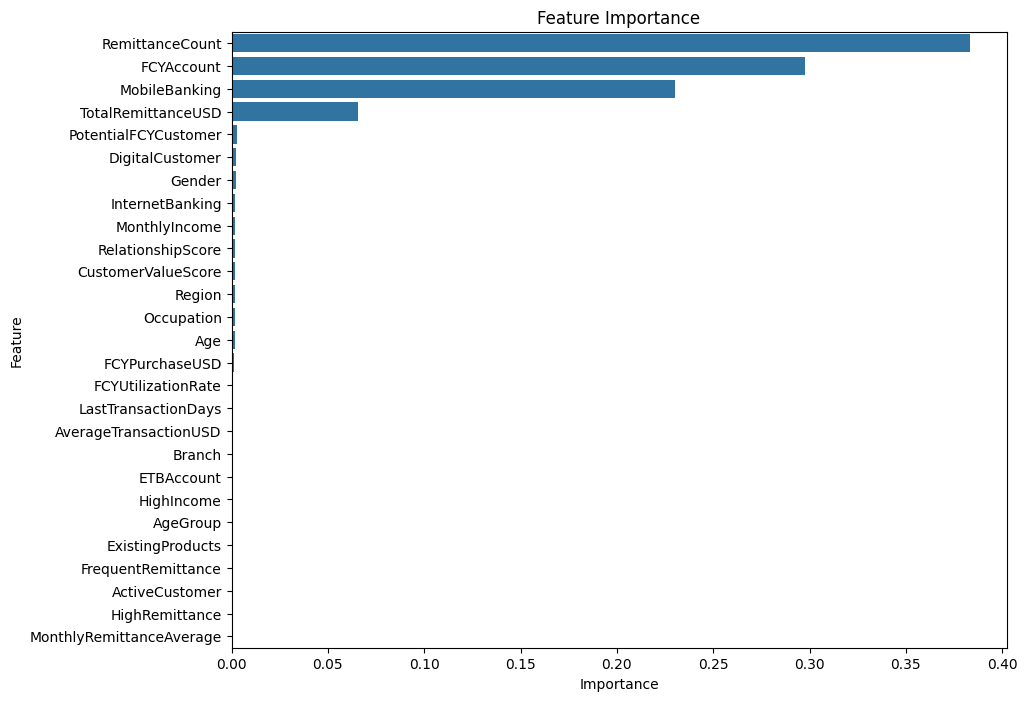

In [18]:
#Plot Feature Importance

plt.figure(figsize=(10,8))

sns.barplot(

data=importance,

x="Importance",

y="Feature"

)

plt.title("Feature Importance")

plt.show()

In [19]:
#Top 10 Most Important Features

importance.head(10)

,Feature,Importance
10,RemittanceCount,0.383111
6,FCYAccount,0.297643
8,MobileBanking,0.230055
11,TotalRemittanceUSD,0.065518
26,PotentialFCYCustomer,0.002909
21,DigitalCustomer,0.002364
1,Gender,0.002077
9,InternetBanking,0.001991
3,MonthlyIncome,0.001795
25,RelationshipScore,0.001792


In [20]:
#Predict High Probability Customers

customers["Probability"] = y_prob

top_leads = customers.sort_values(

by="Probability",

ascending=False

)

top_leads.head(20)

,CustomerID,Age,Gender,Occupation,MonthlyIncome,Region,Branch,FCYAccount,ETBAccount,MobileBanking,...,FrequentRemittance,HighRemittance,ActiveCustomer,DigitalCustomer,CustomerValueScore,MonthlyRemittanceAverage,FCYUtilizationRate,RelationshipScore,PotentialFCYCustomer,Probability
324,100325,23,0,7,84240,5,7,0,1,1,...,1,1,0,1,28403.5,455.25,0.305327,5,1,0.992390
352,100353,37,0,8,136982,2,5,0,1,1,...,1,1,0,1,45106.6,602.00,0.262874,5,1,0.992239
189,100190,26,0,5,89576,3,6,0,1,1,...,1,0,0,1,29180.8,318.00,0.352463,5,1,0.992239
149,100150,52,1,4,115409,6,0,0,1,1,...,1,1,0,1,39710.7,681.33,0.273239,8,1,0.992141
367,100368,55,1,4,133237,6,2,0,1,1,...,1,0,0,1,42831.6,376.75,0.231365,6,1,0.992141
81,100082,60,0,0,161381,2,2,0,1,1,...,1,1,0,1,52911.8,682.92,0.271751,5,1,0.992026
208,100209,23,0,0,90714,2,1,0,1,1,...,1,1,0,1,32044.2,771.67,0.307667,4,1,0.992026
299,100300,60,1,5,175189,0,2,0,1,1,...,1,0,0,1,54580.7,304.00,0.295230,4,1,0.991985
107,100108,55,1,3,149710,2,4,0,1,1,...,1,1,0,1,50053.0,723.33,0.252304,7,1,0.991765
26,100027,42,1,2,138503,4,4,0,1,1,...,1,0,0,1,43615.9,277.50,0.339339,5,1,0.991765


In [21]:
#Save Evaluation Results

importance.to_csv(

"Feature_Importance.csv",

index=False

)

top_leads.to_csv(

"Top_Lead_Customers.csv",

index=False

)

print("Evaluation Results Saved")

Evaluation Results Saved


Business Interpretation

Suppose the top five important features are:

Feature	Business Meaning
RemittanceCount	Customers receiving foreign currency frequently are strong FCY prospects.
TotalRemittanceUSD	Higher remittance volume indicates greater FCY potential.
FCYAccount	Customers without an FCY account may represent new acquisition opportunities.
CustomerValueScore	High-value customers deserve priority outreach.
RelationshipScore	Customers using multiple banking services are more likely to respond positively.

This insight can help relationship managers focus their campaigns on customers most likely to convert.

A Critical Issue With Our Current Project

As your mentor, I want to point out something important.

Our dataset was generated using this rule:

LeadStatus =

No FCY Account

AND

RemittanceCount >= 8

AND

TotalRemittanceUSD >= 4000

AND

MobileBanking == Yes

Because of this, the model is essentially learning the same rule that created the target. This means:

The evaluation metrics (Accuracy, AUC, etc.) will likely be artificially high.
Feature importance will naturally highlight those same variables.
This is expected in a synthetic proof-of-concept, but it is not representative of a production banking model.

In a real deployment, LeadStatus would come from historical campaign outcomes (whether customers actually accepted an FCY product), making the learning problem much more realistic.